In [2]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [3]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [4]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [5]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_dark_blue_to_pink = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(1.0)])

In [6]:
spin = 0.5
GAMMA = 2 * np.pi * 42.6e6
K = (3 / 2) * (cst.mu_0 / 4 / np.pi) ** 2 \
    * cst.hbar ** 2 * GAMMA ** 4 * spin * (1 + spin)  # m6 / s2

In [7]:
filename = "nmr-water-silica-temp"
colors = cmap_dark_blue_to_pink(np.linspace(0, 1, 50))

WARNING, text_content specified without text_position 
WARNING, text_content specified without text_position 


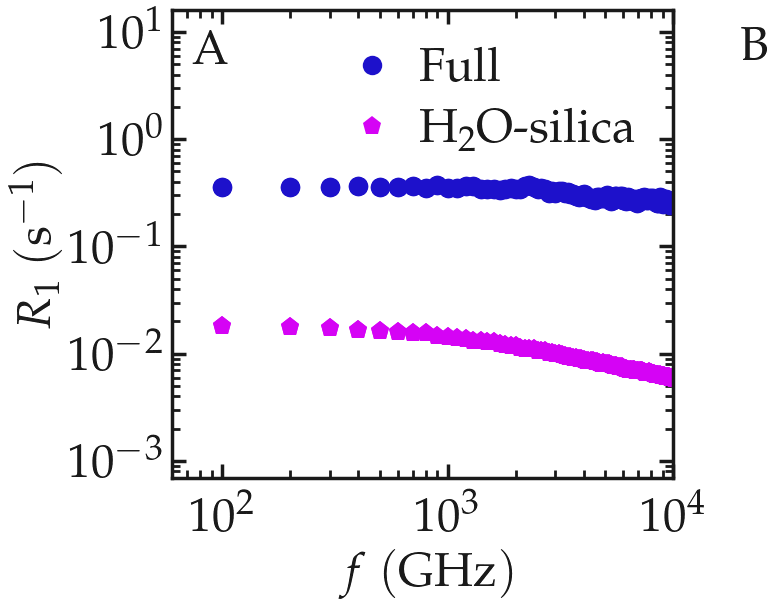

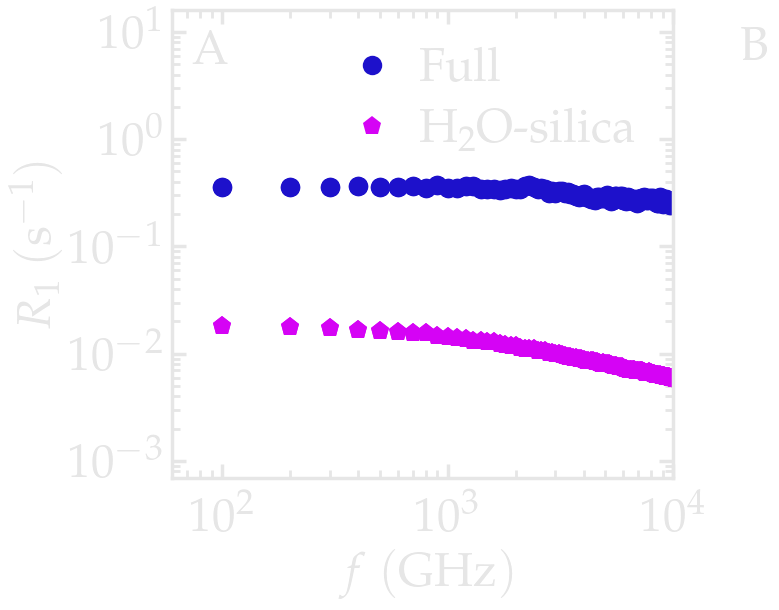

In [9]:
for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (13,6.2), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)
    
    # # Panel 1
    # myplt.add_panel()

    # data_path = git_path + "/.submodules/dataset-water-in-silica/analysis/nmr_full/"
    # data = np.load(data_path + "result500-0.npy", allow_pickle=True).item()
    # C = data["C"]; t = data["t"]
    # myplt.add_plot(x = t, y = C[0], type = "loglog", linewidth_data = 3,
    #             marker = "o", data_color = colors[0], markersize = 13, data_label = r'$G^{0}$')
    # myplt.add_plot(x = t, y = C[1], type = "loglog", linewidth_data = 3,
    #             marker = "p", data_color = colors[25], markersize = 14, data_label = r'$G^{1}$')
    # myplt.add_plot(x = t, y = C[2], type = "loglog", linewidth_data = 3,
    #             marker = "s", data_color = colors[-1], markersize = 14, data_label = r'$G^{2}$')

    # myplt.complete_panel(ylabel = r'$G_{ij}~(\mathrm{\AA{}}^{-6})$', xlabel = r'$t~(\mathrm{ps})$',
    #                      xpad = 15, legend=True, handlelength_legend=1)
    # myplt.set_boundaries(x_boundaries=(1, 1000), y_boundaries=(1e-6, 0.1))

    # Panel 2
    myplt.add_panel()

    data_path = git_path + "/.submodules/dataset-water-in-silica/analysis/nmr_full/"
    data = np.load(data_path + "result500-0.npy", allow_pickle=True).item()
    R1 = data["R1"]; R1_err = data["R1_err"]; f = data["f"]
    myplt.add_plot(x = f, y = R1, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0], markersize = 14, data_label = r'Full')
    
    data_path = git_path + "/.submodules/dataset-water-in-silica/analysis/nmr_water_silica/"
    data = np.load(data_path + "result500-0.npy", allow_pickle=True).item()
    R1 = data["R1"]; R1_err = data["R1_err"]; f = data["f"]
    myplt.add_plot(x = f, y = R1, type = "loglog", linewidth_data = 3,
                marker = "p", data_color = colors[-10], markersize = 14, data_label = r'H$_2$O-silica')

    # data_path = git_path + "/.submodules/dataset-water-in-silica/analysis/nmr_water_inter/"
    # data = np.load(data_path + "result500-0.npy", allow_pickle=True).item()
    # R1T = data["R1"]; R1_errT = data["R1_err"]; f = data["f"]
    # data_path = git_path + "/.submodules/dataset-water-in-silica/analysis/nmr_water_intra/"
    # data = np.load(data_path + "result500-0.npy", allow_pickle=True).item()
    # R1R = data["R1"]; R1_errR = data["R1_err"]; f = data["f"]
    # myplt.add_plot(x = f, y = R1T+R1R, type = "loglog", linewidth_data = 3,
    #             marker = "p", data_color = colors[25], markersize = 14, data_label = r'H$_2$O')

    myplt.complete_panel(ylabel = r'$R_1~(\mathrm{s}^{-1})$', xlabel = r'$f~(\mathrm{GHz})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(60, 10000), y_boundaries=(0.0007, 16)) # , x_ticks = [40, 80, 120, 160])
   
    myplt.add_text(text_content = "B")
    myplt.add_text(text_position = [20000, 11])

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = filename, saving_path = git_path+path_figures)

In [36]:
from PIL import Image

right_padding = 950  # pixels of extra space

for i in [1, 2]:
    if i == 1:
        figure_path = "nmr-water-silica-temp.png"
        insert_path = "snapshot-light.png"
        output_path = "nmr-water-silica.png"
    else:
        figure_path = "nmr-water-silica-temp-dm.png"
        insert_path = "snapshot-dark.png"
        output_path = "nmr-water-silica-dm.png"

    figure = Image.open(figure_path).convert("RGBA")
    insert = Image.open(insert_path).convert("RGBA")

    # Create a larger canvas
    canvas = Image.new(
        "RGBA",
        (figure.width + right_padding, figure.height),
        (0, 0, 0, 0),
    )
    canvas.alpha_composite(figure, (0, 0))

    # # Start from the spectrum itself — preserves its own background/transparency
    # canvas = figure.copy()

    scale = 0.6
    target_w = int(figure.width * scale)
    target_h = int(insert.height * (target_w / insert.width))
    legend_resized = insert.resize((target_w, target_h), Image.LANCZOS)

    top_margin = 10
    lat_margin = 0
    x = figure.width + right_padding - target_w - lat_margin
    y = top_margin

    canvas.alpha_composite(legend_resized, (x, y))

    canvas.save(output_path)  # keep as PNG with alpha, don't convert to RGB
    print(f"Saved {output_path}")

Saved nmr-water-silica.png
Saved nmr-water-silica-dm.png


Saved nmr-relaxation-rates-at-target.png
Saved nmr-relaxation-rates-at-target-dm.png


In [14]:
# filename = "nmr-relaxation-rates-spectra"
# colors = cmap_cool(np.linspace(0, 1, len(all_temperatures)))

# for dark_mode in [False, True]:

#     myplt = PltTools()
#     myplt.prepare_figure(fig_size = (18,6), dark_mode = dark_mode,
#                          transparency = True, use_serif=True, n_colone = 2)
#     # Panel 1
#     myplt.add_panel()
#     for T, color in zip(all_temperatures, colors):
#         f, R1 = np.loadtxt(data_path+f"T{T}/R1_vs_f.dat").T
#         if ((T == all_temperatures[0]) | (T == all_temperatures[-1])):
#             myplt.add_plot(x = f, y = R1*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12,
#                         data_label = f'$T = {np.int32(T*ref_temp)}~\mathrm K$')
#         else:
#             myplt.add_plot(x = f, y = R1*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12) 
#     myplt.complete_panel(ylabel = r'$R_1~(\mathrm{ms}^{-1})$', xlabel = r'$f~(\mathrm{MHz})$',
#                          xpad = 15, legend=True, handlelength_legend=1)
#     myplt.set_boundaries(x_boundaries=(2e4, 3e7), y_boundaries=(4e-2, 2e1))
#     # Panel 2
#     myplt.add_panel()
#     for T, color in zip(all_temperatures, colors):
#         f, R2 = np.loadtxt(data_path+f"T{T}/R2_vs_f.dat").T
#         if ((T == all_temperatures[0]) | (T == all_temperatures[-1])):
#             myplt.add_plot(x = f, y = R2*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12,
#                         data_label = f'$T = {np.int32(T*ref_temp)}~\mathrm K$')
#         else:
#             myplt.add_plot(x = f, y = R2*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12) 
#     myplt.complete_panel(ylabel = r'$R_2~(\mathrm{ms}^{-1})$', xlabel = r'$f~(\mathrm{MHz})$',
#                          xpad = 15, legend=True, handlelength_legend=1)
#     myplt.set_boundaries(x_boundaries=(2e4, 3e7), y_boundaries=(4e-1, 2e1))
#     myplt.add_subplotlabels(type_label_panel = "A")
#     myplt.save_figure(filename = filename, saving_path = git_path+path_figures)
